In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)


df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Exploratory Data Analysis (EDA)


In [54]:
# Shape of dataset
print("Shape:", df.shape)

Shape: (32581, 12)


In [99]:
# Summary stats (numerical)
print('=== Numerical Features ===')
df.describe()

=== Numerical Features ===


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [72]:
# Summary stats (categorical)
print('=== Categorical Features ===')
df.describe(include=["object", "category"])

=== Categorical Features ===


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


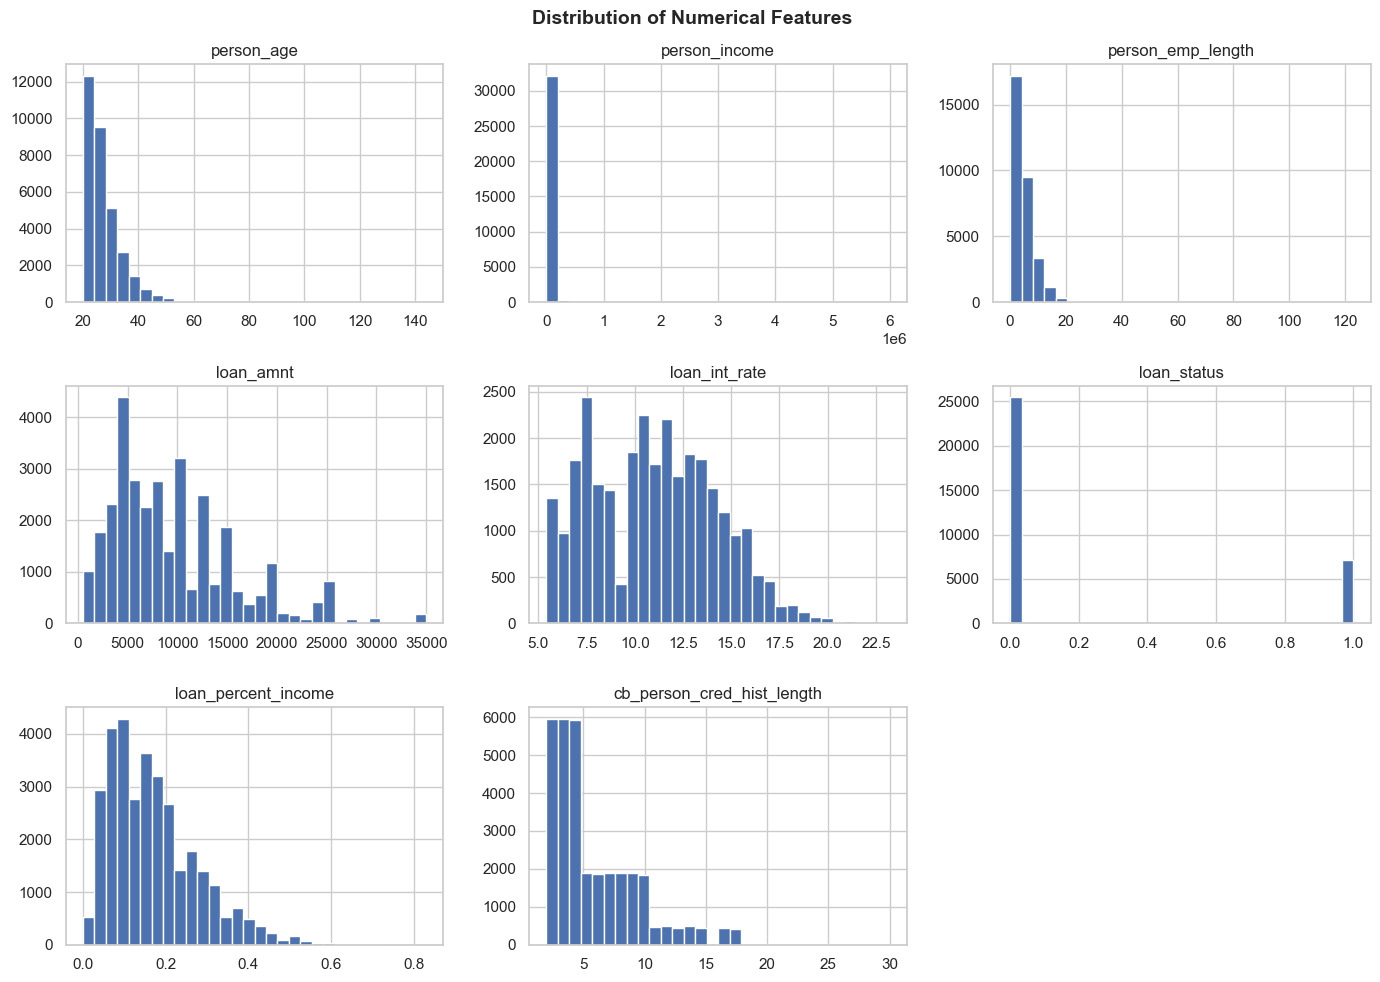

In [73]:
df.hist(bins=30, figsize=(14, 10))
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

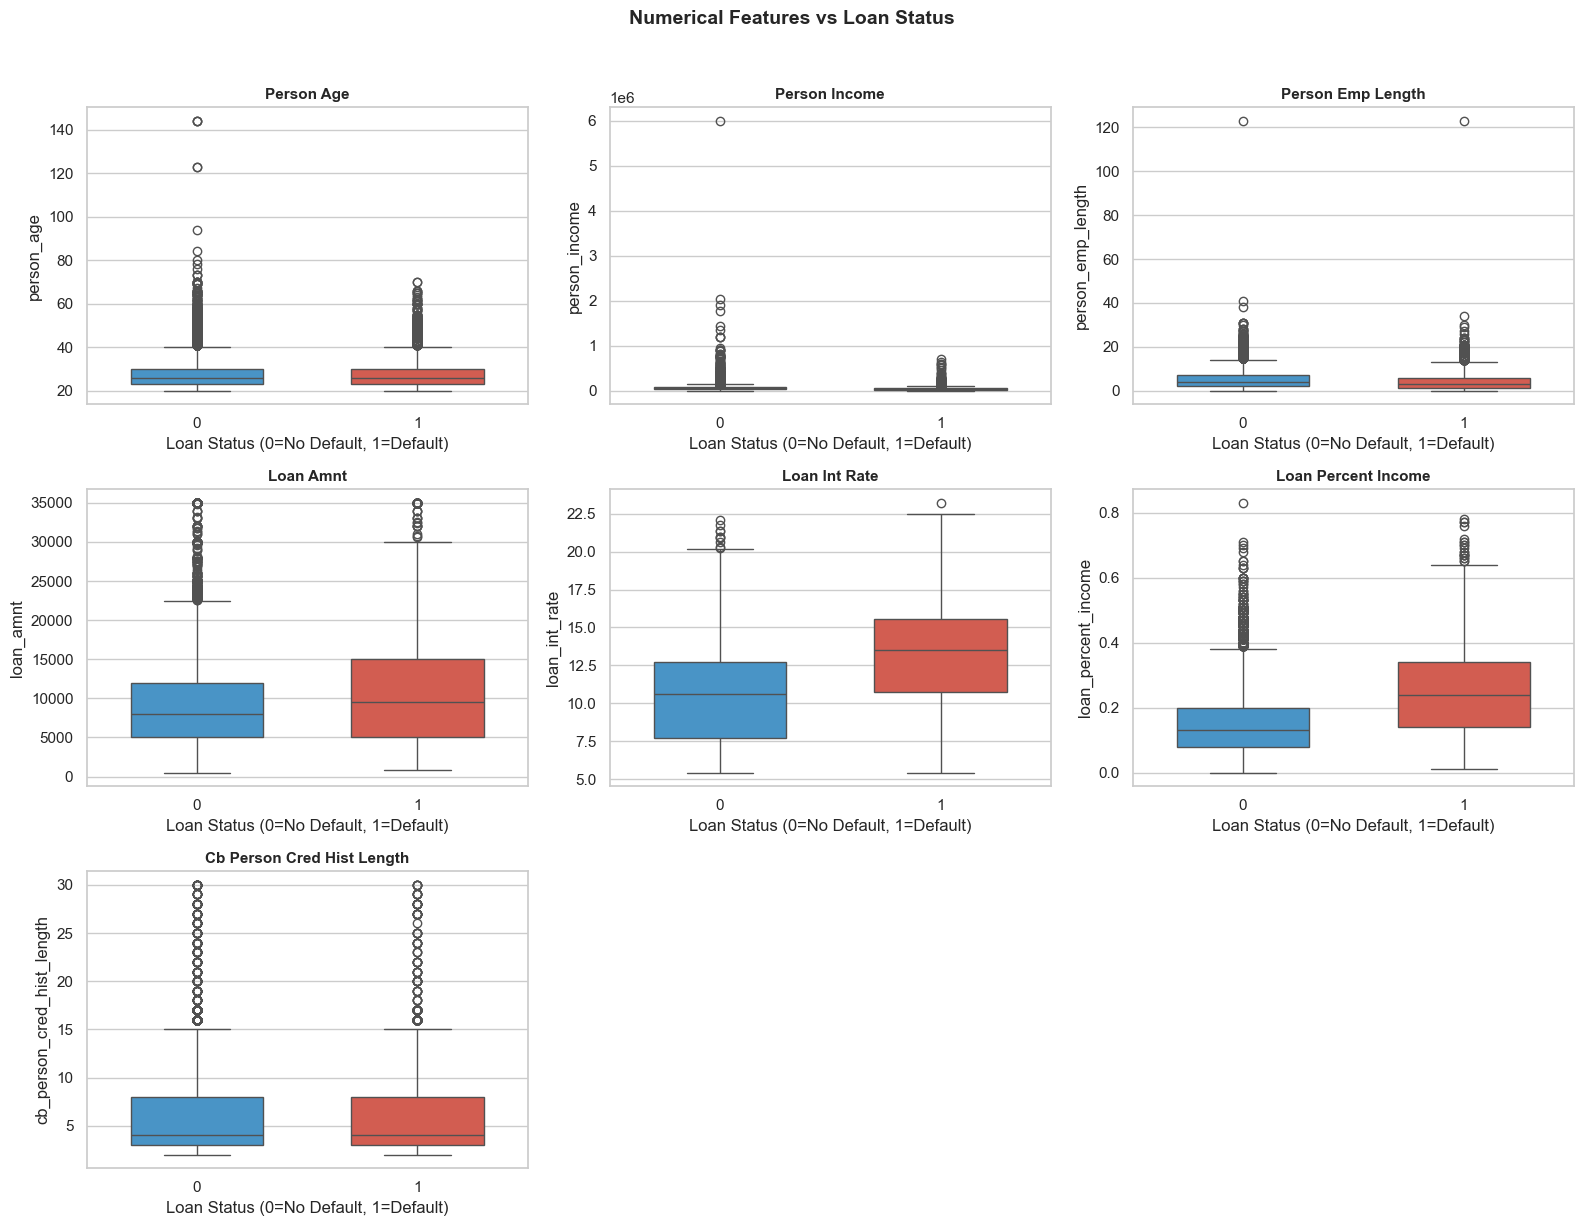

In [74]:
numerical_features = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        x='loan_status', y=feature, data=df,
        hue='loan_status', legend=False,
        width=0.6, palette=['#3498db', '#e74c3c'],
        ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' ').title(),
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Loan Status (0=No Default, 1=Default)')

for j in range(len(numerical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Loan Status', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

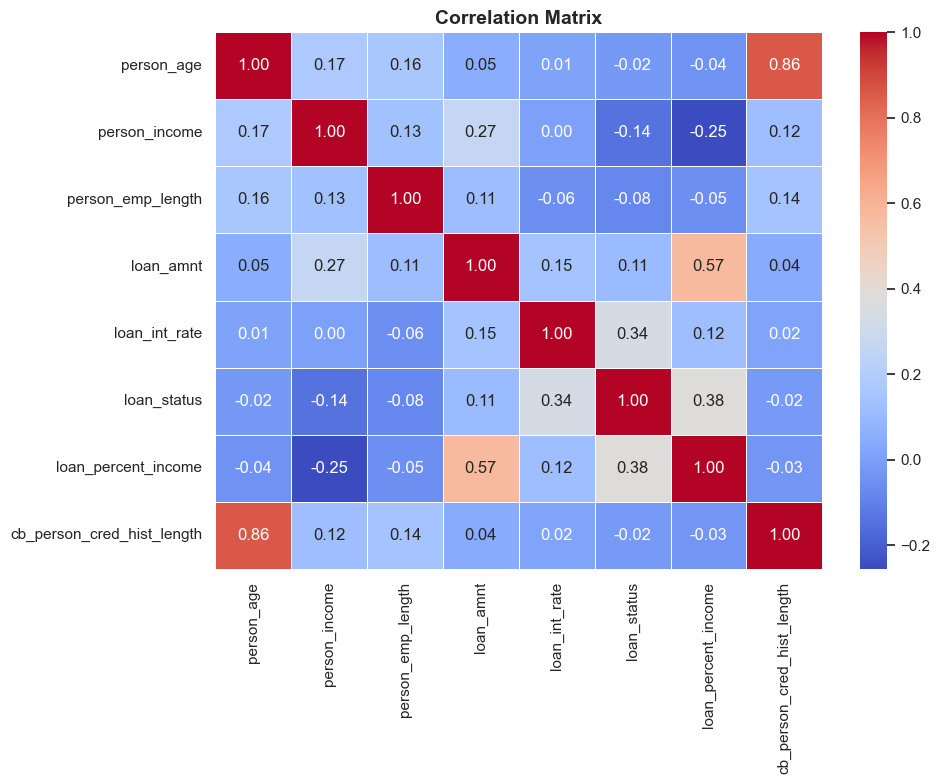

In [59]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_cols.corr(),
            annot=True,cmap='coolwarm',
            fmt='.2f',linewidths=0.5)

plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Missing Data Analysis

In [60]:
# Count and percentage of missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent.round(3)})

# Only show columns that have missing values
missing_table = missing_table[missing_table['Missing Count'] > 0]
print(missing_table)

                   Missing Count  Missing Percentage (%)
person_emp_length            895                   2.747
loan_int_rate               3116                   9.564


/var/folders/v2/2hgjvxh116gd4gxk_0bjm7m40000gn/T/ipykernel_86987/3533254725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_table.index,


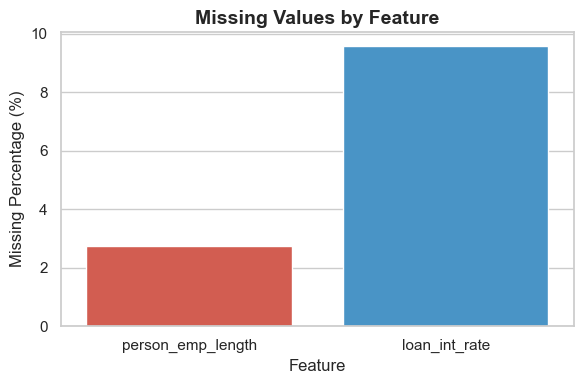

In [76]:
# Missing values bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=missing_table.index,
            y=missing_table['Missing Percentage (%)'],
            palette=['#e74c3c', '#3498db'])

plt.title('Missing Values by Feature', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Missing Percentage (%)')
plt.tight_layout()
plt.show()

In [77]:
print('=== Outlier Investigation ===')
print('Rows with age above 100:', (df['person_age'] > 100).sum())
print('Rows with emp_length above 60:', (df['person_emp_length'] > 60).sum())

print('\n=== Age Outlier Rows ===')
print(df[df['person_age'] > 100][['person_age', 'person_income',
                                    'person_emp_length', 'loan_amnt',
                                    'loan_status']])

print('\n=== Employment Length Outlier Rows ===')
print(df[df['person_emp_length'] > 60][['person_age', 'person_income',
                                          'person_emp_length', 'loan_amnt',
                                          'loan_status']])

=== Outlier Investigation ===
Rows with age above 100: 5
Rows with emp_length above 60: 2

=== Age Outlier Rows ===
       person_age  person_income  person_emp_length  loan_amnt  loan_status
81            144         250000                4.0       4800            0
183           144         200000                4.0       6000            0
575           123          80004                2.0      20400            0
747           123          78000                7.0      20000            0
32297         144        6000000               12.0       5000            0

=== Employment Length Outlier Rows ===
     person_age  person_income  person_emp_length  loan_amnt  loan_status
0            22          59000              123.0      35000            1
210          21         192000              123.0      20000            0


In [78]:
print('Shape before outlier removal:', df.shape)

# Remove rows with impossible ages (entire row is corrupt)
df = df[df['person_age'] <= 100]

# Imputing impossible employment lengths (only emp_length is wrong,
# rest of row is valid, age 21/22 is realistic)
median_emp = df[df['person_emp_length'] <= 60]['person_emp_length'].median()
df['person_emp_length'] = df['person_emp_length'].apply(
    lambda x: median_emp if x > 60 else x
)

print('Shape after outlier removal:', df.shape)
print('Rows removed:', 32581 - len(df))
print('Max person_age:', df['person_age'].max())
print('Max person_emp_length:', df['person_emp_length'].max())

Shape before outlier removal: (32581, 12)
Shape after outlier removal: (32576, 12)
Rows removed: 5
Max person_age: 94
Max person_emp_length: 41.0


In [80]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding - ordinal and binary variables
le = LabelEncoder()

# loan_grade is ordinal (A=best, G=worst)
df['loan_grade_encoded'] = le.fit_transform(df['loan_grade'])

# cb_person_default_on_file is binary (Y/N)
df['cb_person_default_on_file_encoded'] = le.fit_transform(df['cb_person_default_on_file'])

# One-Hot Encoding - nominal variables (no natural order)
df = pd.get_dummies(df,columns=['person_home_ownership', 'loan_intent'],drop_first=True)

# Drop original categorical columns that have been encoded
df = df.drop(columns=['loan_grade', 'cb_person_default_on_file'])

print('Encoding complete')
print('Columns after encoding:', df.columns.tolist())

Encoding complete
Columns after encoding: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade_encoded', 'cb_person_default_on_file_encoded', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


**Data Splitting**

In [81]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

# stratify=y preserves class balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)
print('\nClass distribution in training set:')
print(y_train.value_counts(normalize=True).round(3))
print('\nClass distribution in test set:')
print(y_test.value_counts(normalize=True).round(3))

Training set size: (26060, 17)
Testing set size: (6516, 17)

Class distribution in training set:
loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64

Class distribution in test set:
loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64


In [82]:
# loan_int_rate — MEAN imputation
# Justified by: skewness=0.21 (approximately normal), mean=11.01 ≈ median=10.99
mean_imputer = SimpleImputer(strategy='mean')
X_train['loan_int_rate'] = mean_imputer.fit_transform(
    X_train[['loan_int_rate']]
)
X_test['loan_int_rate'] = mean_imputer.transform(
    X_test[['loan_int_rate']]
)

# person_emp_length — MEDIAN imputation
median_imputer = SimpleImputer(strategy='median')

X_train['person_emp_length'] = median_imputer.fit_transform(X_train[['person_emp_length']])

X_test['person_emp_length'] = median_imputer.transform(X_test[['person_emp_length']])

#checks if any missing values remain
print('Missing values in X_train after imputation:')
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print('\nMissing values in X_test after imputation:')
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])
print('\nImputation complete — no missing values remain')

Missing values in X_train after imputation:
Series([], dtype: int64)

Missing values in X_test after imputation:
Series([], dtype: int64)

Imputation complete — no missing values remain


In [84]:
# Compute correlation with target on training data only
train_with_target = X_train.copy()
train_with_target['loan_status'] = y_train.values

correlation_with_target = train_with_target.corr()['loan_status'].drop('loan_status')
correlation_with_target = correlation_with_target.sort_values(ascending=False)

print('=== Feature Correlations with loan_status ===')
print(correlation_with_target.round(4))

=== Feature Correlations with loan_status ===
loan_percent_income                  0.3816
loan_grade_encoded                   0.3722
loan_int_rate                        0.3180
person_home_ownership_RENT           0.2425
cb_person_default_on_file_encoded    0.1803
loan_amnt                            0.1072
loan_intent_MEDICAL                  0.0587
loan_intent_HOMEIMPROVEMENT          0.0376
person_home_ownership_OTHER          0.0184
cb_person_cred_hist_length          -0.0134
person_age                          -0.0173
loan_intent_PERSONAL                -0.0212
loan_intent_EDUCATION               -0.0512
loan_intent_VENTURE                 -0.0780
person_emp_length                   -0.0840
person_home_ownership_OWN           -0.1011
person_income                       -0.1703
Name: loan_status, dtype: float64


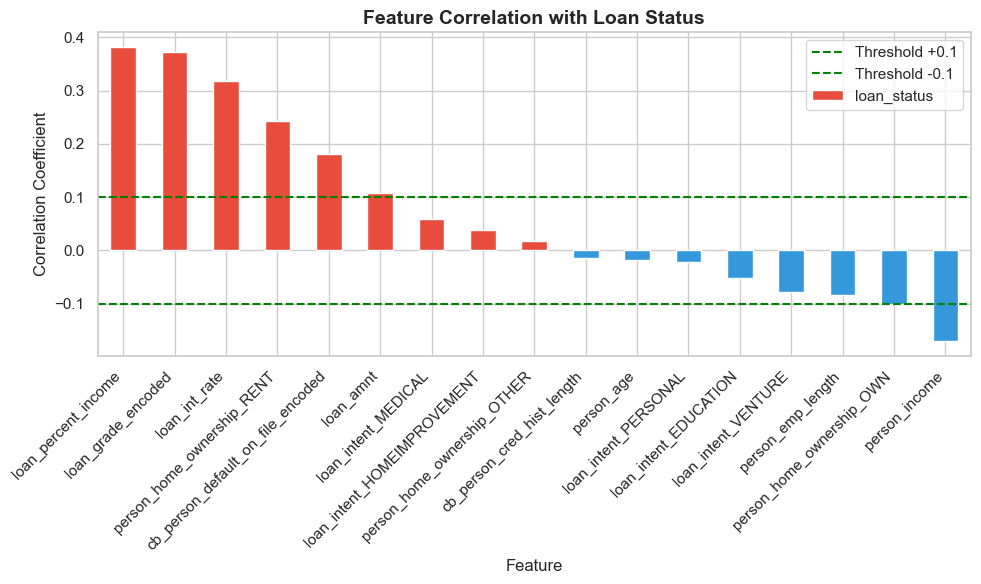

In [85]:
# Plot feature correlation bar chart
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db'
          for x in correlation_with_target]
correlation_with_target.plot(kind='bar', color=colors)

plt.axhline(y=0.1, color='green', linestyle='--',
            linewidth=1.5, label='Threshold +0.1')
plt.axhline(y=-0.1, color='green', linestyle='--',
            linewidth=1.5, label='Threshold -0.1')

plt.title('Feature Correlation with Loan Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [86]:
# Apply threshold to select features
threshold = 0.1
selected_features = correlation_with_target[
    abs(correlation_with_target) > threshold
].index.tolist()

dropped_features = correlation_with_target[
    abs(correlation_with_target) <= threshold
].index.tolist()

print('Selected features:', selected_features)
print('\nDropped features:', dropped_features)

# Apply feature selection to both train and test
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print('\nShape after feature selection:')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

Selected features: ['loan_percent_income', 'loan_grade_encoded', 'loan_int_rate', 'person_home_ownership_RENT', 'cb_person_default_on_file_encoded', 'loan_amnt', 'person_home_ownership_OWN', 'person_income']

Dropped features: ['loan_intent_MEDICAL', 'loan_intent_HOMEIMPROVEMENT', 'person_home_ownership_OTHER', 'cb_person_cred_hist_length', 'person_age', 'loan_intent_PERSONAL', 'loan_intent_EDUCATION', 'loan_intent_VENTURE', 'person_emp_length']

Shape after feature selection:
X_train: (26060, 8)
X_test: (6516, 8)


In [87]:
scaler = StandardScaler()

# fit_transform on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test data — no fitting
X_test_scaled = scaler.transform(X_test)

print('Scaling complete')
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)

Scaling complete
X_train_scaled shape: (26060, 8)
X_test_scaled shape: (6516, 8)


In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression — uses scaled data
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train_scaled, y_train)
print('Logistic Regression trained')

# Decision Tree — does not need scaling
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print('Decision Tree trained')

# Random Forest — does not need scaling
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
print('Random Forest trained')

print('\nAll models trained successfully')

Logistic Regression trained
Decision Tree trained
Random Forest trained

All models trained successfully


In [94]:
models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Decision Tree': (dt, X_test),
    'Random Forest': (rf, X_test)
}
results = []

for name, (model, X_data) in models.items():
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8516     0.7387  0.4951    0.5928   0.8533
      Decision Tree    0.8697     0.6975  0.7117    0.7045   0.8131
      Random Forest    0.8995     0.8303  0.6779    0.7464   0.9100


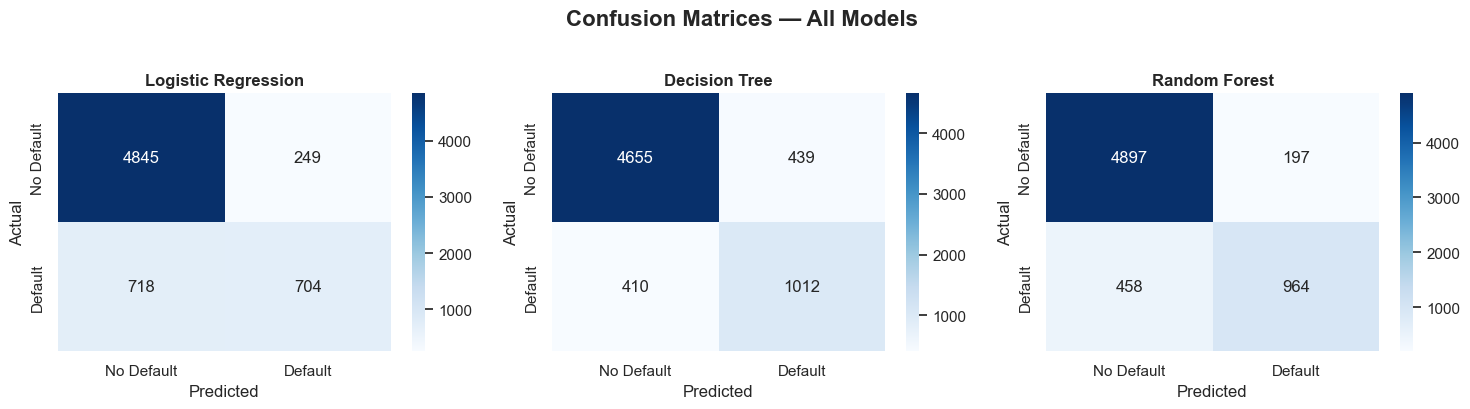

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (model, X_data)) in zip(axes, models.items()):
    y_pred = model.predict(X_data)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])

    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

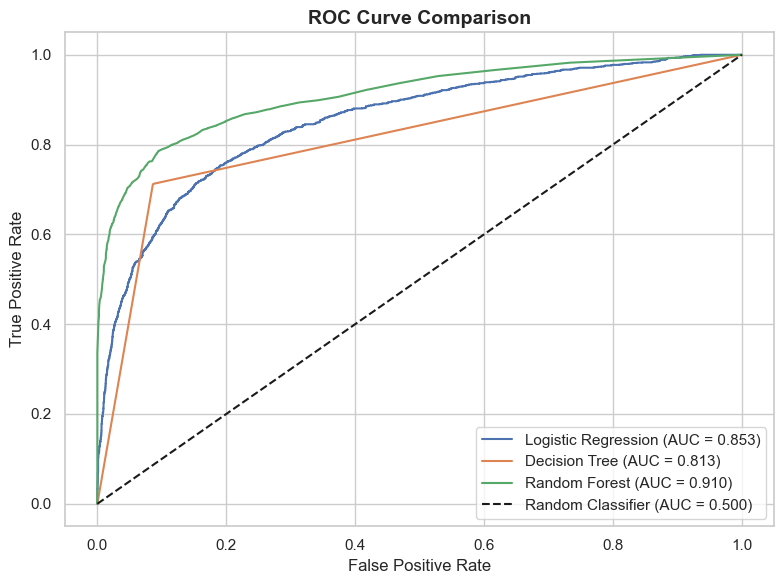

In [96]:
plt.figure(figsize=(8, 6))

for name, (model, X_data) in models.items():
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

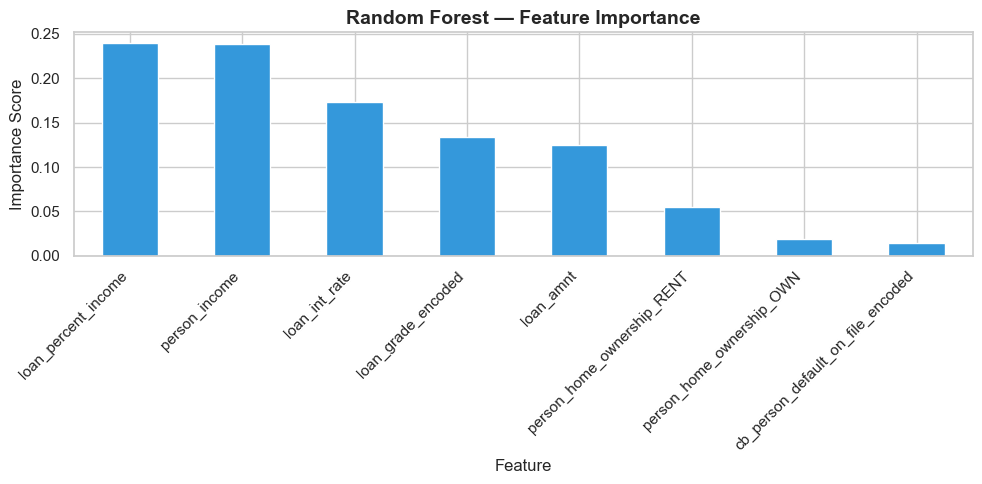


Top 5 most important features:
loan_percent_income    0.239683
person_income          0.238710
loan_int_rate          0.173626
loan_grade_encoded     0.134065
loan_amnt              0.125309
dtype: float64


In [97]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='#3498db')
plt.title('Random Forest — Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importance.head())

In [98]:
print('=== Final Model Performance Comparison ===')
print(results_df.to_string(index=False))

best_model = results_df.loc[results_df['F1 Score'].idxmax(), 'Model']
best_auc = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_recall = results_df.loc[results_df['Recall'].idxmax(), 'Model']

print(f'\nBest F1 Score: {best_model}')
print(f'Best ROC-AUC: {best_auc}')
print(f'Best Recall: {best_recall}')

=== Final Model Performance Comparison ===
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8516     0.7387  0.4951    0.5928   0.8533
      Decision Tree    0.8697     0.6975  0.7117    0.7045   0.8131
      Random Forest    0.8995     0.8303  0.6779    0.7464   0.9100

Best F1 Score: Random Forest
Best ROC-AUC: Random Forest
Best Recall: Decision Tree
